This notebook is designed to test the impact of a custom filter such that
some portion of particles are propagated by, dt/2 and (u2-u1)/2, to mitigate weight degeneracy problem.

The parameters are fixed in this experiments as follows:
 - Error metric is Mean Absolute Error
 - Setup2 (IMU, VO+GPS)
 - Kitti dataset sequence 09 (0033)
 - 256 particles
 - 20% of particles take intermediate IMU data and time delta to propagate
 - STRATIFIED resampling algorithm
 - Control group = normal particle filter (current implementation)
 - Experiment group = particle filter with intermediate control input data (new particle filter)
 - The filter result is stored in binary such that if the error exceeds certain threshold, 10,000, the filter is considered to be diverged.

Both filters are executed 100 times and check the impact by Chi-square independence test with 95% confidence interval.


In [1]:
import os
import sys
src_path = '../../../src'
if src_path not in sys.path:
    sys.path.append(src_path)
import numpy as np
import pandas as pd
from tqdm import tqdm
from data_loader import DataLoader
from configs import SetupEnum, MeasurementDataEnum, ErrorEnum, FilterEnum, NoiseTypeEnum
from kalman_filters.particle_filter import ResamplingAlgorithms, ParticleFilter
from kalman_filters.custom_particle_filter import CustomParticleFilter

%matplotlib inline
np.random.seed(777)

In [2]:
setup = SetupEnum.SETUP_2
noise_type = NoiseTypeEnum.CURRENT
resampling_algorithm = ResamplingAlgorithms.STRATIFIED
early_propagation_ratio = 0.2
number_of_samples = 256

iterrations = 100

divergence_threshold = 10_000

kitti_drive = '0033'
root_path = "../../../"
file_export_path = os.path.join(root_path, "exports/particle_filter")
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")

control_errors = []
experiment_errors = []

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Data sampling is set to normal mode.


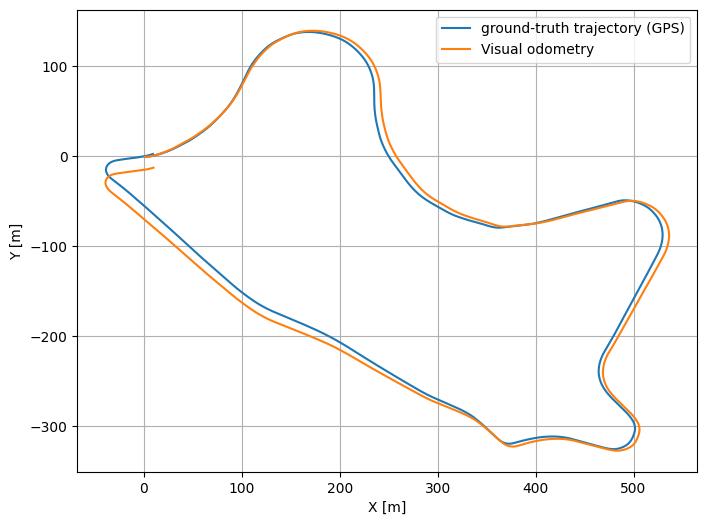

In [3]:
data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0,
                  visualize_data=True)

In [4]:
x, P, H, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)

In [5]:
for i in tqdm(range(iterrations)):
    pf = ParticleFilter(
        N=number_of_samples, 
        x_dim=x.shape[0], 
        H=H.copy(), 
        q=q2,
        r_vo=r_vo2,
        r_gps=r_gps2,
        setup=setup,
        resampling_algorithm=resampling_algorithm)
    pf.create_gaussian_particles(mean=x.copy(), var=P.copy())
    
    error_pf = pf.run(data=data, debug_mode=False)
    control_errors.append(error_pf)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [19:33<00:00, 11.74s/it]


In [6]:
for i in tqdm(range(iterrations)):
    custom_pf = CustomParticleFilter(N=number_of_samples, 
                                     x_dim=x.shape[0], 
                                     H=H.copy(), 
                                     resampling_algorithm=resampling_algorithm)
    custom_pf.create_gaussian_particles(mean=x.copy(), var=P.copy())
    error_custom_pf = custom_pf.run(data=data, 
                                    debug_mode=False,
                                    setup=setup,
                                    measurement_type=MeasurementDataEnum.ALL_DATA)
    experiment_errors.append(error_custom_pf)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [24:06<00:00, 14.47s/it]


In [7]:
constrol_0 = np.array([error[ErrorEnum.MAE] > divergence_threshold for error in control_errors])
experiment_0 = np.array([error[ErrorEnum.MAE] > divergence_threshold for error in experiment_errors])

In [16]:
c_val = 3.84
control_success = len(constrol_0[constrol_0 == False])
control_failure = len(constrol_0) - control_success
experiment_success = len(experiment_0[experiment_0 == False])
experiment_failure = len(experiment_0) - experiment_success

control_total = control_success + control_failure
experiment_total = experiment_success + experiment_failure
success_total = control_success + experiment_success
failure_total = control_failure + experiment_failure
ground_total = control_total + experiment_total

print(f"control group success count: {control_success}")
print(f"experiment group sucesss count: {experiment_success}")

control group success count: 39
experiment group sucesss count: 41


In [9]:
E11 = (control_total * success_total) / ground_total
E12 = (control_total * failure_total) / ground_total
E21 = (experiment_total * success_total) / ground_total
E22 = (experiment_total * failure_total) / ground_total

In [10]:
E = np.array([E11, E12, E21, E22])
O = np.array([control_success, control_failure, experiment_success, experiment_failure])

In [11]:
p_value = np.sum((E - O) **2 / E)
print(f"P value: {p_value}, critical value: {c_val} for 1 dof and alpha = 0.05.")

P value: 0.08333333333333334, critical value: 3.84 for 1 dof and alpha = 0.05.


In [12]:
if p_value > c_val:
    print(f"Since p value, {p_value}, is larger than the critical value, {c_val}, reject the null hypothesis indicating that there is a statistically significant relationship between the setting (control vs. experiment) and the outcomes (success or failure).")
else:
    print(f"Since p value, {p_value}, is not greater than the critical value, {c_val}, there is not enough evidence to reject the null hypothesis, suggesting that the difference in success rates between the control and experiment settings may not be statistically significant.")



Since p value, 0.08333333333333334, is not greater than the critical value, 3.84, there is not enough evidence to reject the null hypothesis, suggesting that the difference in success rates between the control and experiment settings may not be statistically significant.


# Conclusion

in this notebook, the experiment that estimate the impact of change of the particle filter's motion model on the filter divergence probability, success rate, by Chi-square independence test with alpha value 0.05.
The result shows that there is not enough evidence to support the null hypothesis that there is a significant relationship between change of the particle filter's motion model and the success rate. 